# Tema 2 - Utilizarea modelelor neurale pentru clasificarea imaginilor

In [2]:
import os, json, random, copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR
from torch.amp import GradScaler, autocast

import torchvision.models as models
from torchvision import transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
	accuracy_score, f1_score, confusion_matrix,
	ConfusionMatrixDisplay, classification_report
)

print('Importuri OK')

/home/balica/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Importuri OK


/home/balica/.local/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error _ssl.c:990: The handshake operation timed out>
  data = fetch_version_info()


---
# Configurare si initializare
---

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*Axes3D.*')
warnings.filterwarnings('ignore', message='.*epoch parameter.*')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
	print(f'GPU: {torch.cuda.get_device_name(0)}')
	print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')

BASE_DIR = Path('.')
MOLE_DIR = BASE_DIR / 'vai-de-pielea-mea'
FACE_DIR = BASE_DIR / 'you-re-on-candid-camera'

for d in ['figures', 'runs', 'checkpoints', 'submissions']:
	os.makedirs(d, exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 5.8 GB


---
# Clase Dataset
---

In [3]:
class MoleDataset(Dataset):
	CLASS_MAP = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
	CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
	MEAN = [0.7646, 0.5464, 0.5712]
	STD = [0.1410, 0.1532, 0.1706]

	def __init__(self, csv_path, img_dir, transform=None):
		self.df = pd.read_csv(csv_path)
		self.img_dir = Path(img_dir)
		self.transform = transform
		self.labels = [self.CLASS_MAP[d] for d in self.df['diagnostic']]

	def __len__(self): return len(self.df)

	def __getitem__(self, idx):
		img = Image.open(self.img_dir / self.df.iloc[idx]['imagine']).convert('RGB')
		lbl = self.labels[idx]
		if self.transform: img = self.transform(img)
		return img, lbl

class MoleTestDataset(Dataset):
	def __init__(self, csv_path, img_dir, transform=None):
		self.df = pd.read_csv(csv_path)
		self.img_dir = Path(img_dir)
		self.transform = transform

	def __len__(self): return len(self.df)

	def __getitem__(self, idx):
		name = self.df.iloc[idx]['imagine']
		img = Image.open(self.img_dir / name).convert('RGB')
		if self.transform: img = self.transform(img)
		return img, name

class FaceDataset(Dataset):
	CLASS_NAMES = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']

	def __init__(self, csv_path, base_dir, transform=None):
		self.df = pd.read_csv(csv_path)
		self.base_dir = Path(base_dir)
		self.transform = transform
		self.labels = [int(l) - 1 for l in self.df['label']]

	def __len__(self): return len(self.df)

	def __getitem__(self, idx):
		img = Image.open(self.base_dir / self.df.iloc[idx]['path']).convert('RGB')
		lbl = self.labels[idx]
		if self.transform: img = self.transform(img)
		return img, lbl

class FaceTestDataset(Dataset):
	def __init__(self, csv_path, base_dir, transform=None):
		self.df = pd.read_csv(csv_path)
		self.base_dir = Path(base_dir)
		self.transform = transform
		test_dir = self.base_dir / 'DATASET' / 'test'
		self._lookup = {f.name: f for sub in test_dir.iterdir()
			if sub.is_dir() for f in sub.iterdir()}

	def __len__(self): return len(self.df)

	def __getitem__(self, idx):
		img_id = self.df.iloc[idx]['id']
		img = Image.open(self._lookup[img_id]).convert('RGB')
		if self.transform: img = self.transform(img)
		return img, img_id

print('Dataset classes OK')

Dataset classes OK


---
# Functii comune de antrenare
---

In [13]:
NUM_WORKERS = 8 if device == 'cuda' else 2
PIN_MEMORY = device == 'cuda'

def make_loader(dataset, batch_size, shuffle, drop_last=False, sampler=None):
	return DataLoader(
		dataset,
		batch_size=batch_size,
		shuffle=(shuffle and sampler is None),
		sampler=sampler,
		num_workers=NUM_WORKERS,
		pin_memory=PIN_MEMORY,
		persistent_workers=(NUM_WORKERS > 0),
		drop_last=drop_last,
	)

print(f'DataLoader: num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY}')

DataLoader: num_workers=8, pin_memory=True


In [9]:
def set_seed(seed=42):
	random.seed(seed); np.random.seed(seed)
	torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

_scaler = GradScaler('cuda')

def train_one_epoch(model, loader, criterion, optimizer, device):
	model.train()
	total_loss, correct, total = 0.0, 0, 0
	use_amp = device == 'cuda'
	for imgs, lbls in loader:
		imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
		optimizer.zero_grad(set_to_none=True)
		with autocast('cuda', enabled=use_amp):
			logits = model(imgs)
			loss = criterion(logits, lbls)
		if use_amp:
			_scaler.scale(loss).backward()
			_scaler.step(optimizer)
			_scaler.update()
		else:
			loss.backward()
			optimizer.step()
		total_loss += loss.item() * imgs.size(0)
		correct += (logits.argmax(1) == lbls).sum().item()
		total += lbls.size(0)
	return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
	model.eval()
	total_loss, correct, total = 0.0, 0, 0
	all_preds, all_labels = [], []
	for imgs, lbls in loader:
		imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
		logits = model(imgs)
		loss = criterion(logits, lbls)
		total_loss += loss.item() * imgs.size(0)
		preds = logits.argmax(1)
		correct += (preds == lbls).sum().item()
		total += lbls.size(0)
		all_preds.extend(preds.cpu().numpy())
		all_labels.extend(lbls.cpu().numpy())
	return total_loss / total, correct / total, all_preds, all_labels

def train_model(model, train_loader, val_loader, criterion, optimizer,
					scheduler, num_epochs, device, run_name, verbose=True,
					unfreeze_schedule=None):
	writer = SummaryWriter(log_dir=f'runs/{run_name}')
	history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
	best_val_f1 = 0.0
	for epoch in range(num_epochs):
		if unfreeze_schedule and epoch in unfreeze_schedule:
			layer, lr = unfreeze_schedule[epoch]
			for p in layer.parameters(): p.requires_grad = True
			optimizer.add_param_group({'params': layer.parameters(), 'lr': lr})
			print(f'  [Epoch {epoch+1}] Deblocat layer, lr={lr}')

		tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
		va_loss, va_acc, va_preds, va_labels = evaluate(model, val_loader, criterion, device)
		va_f1 = f1_score(va_labels, va_preds, average='macro', zero_division=0)
		if scheduler is not None: scheduler.step()
		history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
		history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
		history['val_f1'].append(va_f1)
		writer.add_scalar('Loss/train', tr_loss, epoch)
		writer.add_scalar('Loss/val', va_loss, epoch)
		writer.add_scalar('Acc/train', tr_acc, epoch)
		writer.add_scalar('Acc/val', va_acc, epoch)
		writer.add_scalar('F1/val', va_f1, epoch)
		writer.add_scalar('LR', optimizer.param_groups[0]['lr'], epoch)
		if va_f1 > best_val_f1:
			best_val_f1 = va_f1
			torch.save(model.state_dict(), f'checkpoints/{run_name}_best.pt')
		if verbose:
			print(f'Epoca {epoch+1:02d}/{num_epochs} | '
					f'train loss={tr_loss:.4f} acc={tr_acc:.3f} | '
					f'val loss={va_loss:.4f} acc={va_acc:.3f} f1={va_f1:.4f}')
	writer.close()
	return history

def plot_history(histories_dict, title, save_path=None):
	fig, axes = plt.subplots(1, 3, figsize=(18, 4))
	for label, h in histories_dict.items():
		axes[0].plot(h['train_loss'], linestyle='--', label=f'{label} train')
		axes[0].plot(h['val_loss'], label=f'{label} val')
		axes[1].plot(h['train_acc'], linestyle='--', label=f'{label} train')
		axes[1].plot(h['val_acc'], label=f'{label} val')
		if 'val_f1' in h:
			axes[2].plot(h['val_f1'], label=label)
	for ax, ylabel in zip(axes[:2], ['Loss', 'Accuracy']):
		ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
		ax.set_title(f'{ylabel} — {title}'); ax.legend(fontsize=7)
	axes[2].set_xlabel('Epoca'); axes[2].set_ylabel('F1-macro')
	axes[2].set_title(f'F1-macro val — {title}'); axes[2].legend(fontsize=7)
	plt.tight_layout()
	if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
	plt.show()

def compute_metrics(model, loader, device, class_names, title='', save_path=None):
	model.eval()
	all_preds, all_labels = [], []
	with torch.no_grad():
		for imgs, lbls in loader:
			preds = model(imgs.to(device)).argmax(1).cpu().numpy()
			all_preds.extend(preds)
			all_labels.extend(lbls.numpy())
	acc = accuracy_score(all_labels, all_preds)
	f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
	f1_micro = f1_score(all_labels, all_preds, average='micro', zero_division=0)
	print(f'=== {title} ===')
	print(f'Accuracy : {acc:.4f}')
	print(f'F1-macro : {f1_macro:.4f}')
	print(f'F1-micro : {f1_micro:.4f}')
	print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
	cm = confusion_matrix(all_labels, all_preds)
	fig, ax = plt.subplots(figsize=(9, 7))
	ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
		ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
	ax.set_title(f'Matrice de confuzie — {title}')
	plt.tight_layout()
	if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
	plt.show()
	return {'accuracy': acc, 'f1_macro': f1_macro, 'f1_micro': f1_micro}

def get_class_weights(dataset, num_classes, device):
	labels = np.array(dataset.labels)
	counts = np.bincount(labels, minlength=num_classes).astype(float)
	weights = counts.sum() / (num_classes * counts)
	return torch.tensor(weights, dtype=torch.float32).to(device)

def get_sampler(dataset, num_classes):
	labels = np.array(dataset.labels)
	counts = np.bincount(labels, minlength=num_classes).astype(float)
	sample_w = (1.0 / counts)[labels]
	return WeightedRandomSampler(
		weights=torch.from_numpy(sample_w).double(),
		num_samples=len(sample_w), replacement=True
	)

print('Functii comune OK')


Functii comune OK


---
# 3.1 Vizualizarea Augmentarilor
---

## Augmentari — 'Vai de pielea mea' (alunite dermatoscopice)


In [7]:
class AlbumWrapper:
	def __init__(self, alb_transform, resize, mean, std):
		self.alb = alb_transform
		self.final = transforms.Compose([
			transforms.Resize((resize, resize)),
			transforms.ToTensor(),
			transforms.Normalize(mean, std),
		])
	def __call__(self, img):
		aug = self.alb(image=np.array(img))['image']
		return self.final(Image.fromarray(aug))

mole_aug_geometric = A.Compose([
	A.HorizontalFlip(p=0.5),
	A.VerticalFlip(p=0.5),
	A.RandomRotate90(p=0.5),
	A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-30, 30), p=0.5),
])

mole_aug_color = A.Compose([
	A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.05, p=0.8),
	A.GaussianBlur(blur_limit=(3, 5), p=0.3),
	A.RandomGamma(gamma_limit=(80, 120), p=0.3),
])

mole_aug_all = A.Compose([
	A.HorizontalFlip(p=0.5),
	A.VerticalFlip(p=0.5),
	A.RandomRotate90(p=0.5),
	A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-30, 30), p=0.5),
	A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.05, p=0.8),
	A.GaussianBlur(blur_limit=(3, 5), p=0.3),
	A.RandomGamma(gamma_limit=(80, 120), p=0.3),
])

def make_mole_transform(aug=None, img_size=96, finetune=False):
	mean = [0.485, 0.456, 0.406] if finetune else MoleDataset.MEAN
	std = [0.229, 0.224, 0.225] if finetune else MoleDataset.STD
	if aug is None:
		return transforms.Compose([
			transforms.Resize((img_size, img_size)),
			transforms.ToTensor(),
			transforms.Normalize(mean, std),
		])
	return AlbumWrapper(aug, img_size, mean, std)

print('Augmentari mole definite.')

Augmentari mole definite.


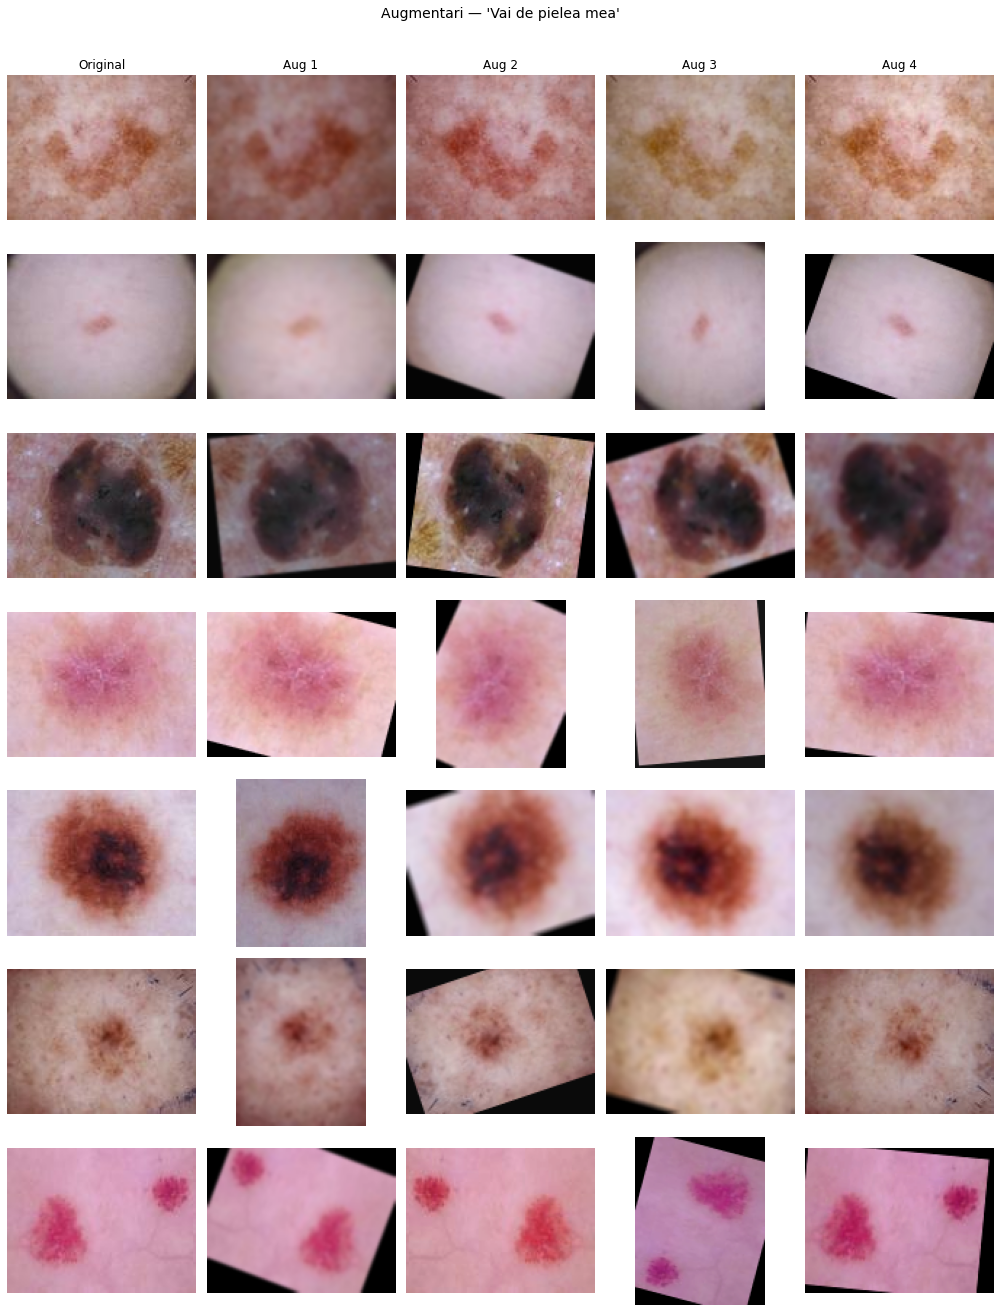

In [7]:
mole_df_vis = pd.read_csv(MOLE_DIR / 'train.csv')
mole_img_dir = MOLE_DIR / 'train'
N_AUG = 4

fig, axes = plt.subplots(7, N_AUG + 1, figsize=(14, 18))
fig.suptitle("Augmentari — 'Vai de pielea mea'", fontsize=14, y=1.01)
for row, cls in enumerate(MoleDataset.CLASS_NAMES):
	sample = mole_df_vis[mole_df_vis['diagnostic'] == cls].iloc[0]
	img_orig = Image.open(mole_img_dir / sample['imagine']).convert('RGB')
	img_np = np.array(img_orig)
	axes[row, 0].imshow(img_orig)
	axes[row, 0].set_ylabel(cls, fontsize=10, fontweight='bold')
	axes[row, 0].set_title('Original' if row == 0 else '')
	axes[row, 0].axis('off')
	for col in range(1, N_AUG + 1):
		aug_img = mole_aug_all(image=img_np)['image']
		axes[row, col].imshow(aug_img)
		axes[row, col].set_title(f'Aug {col}' if row == 0 else '')
		axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('figures/fig_01_aug_mole.png', dpi=150, bbox_inches='tight')
plt.show()

## Augmentari — 'You're on candid camera' (expresii faciale)


In [8]:
with open(FACE_DIR / 'splits' / 'norm_stats.json') as f:
	face_stats = json.load(f)
FACE_MEAN = face_stats['mean']
FACE_STD = face_stats['std']

face_aug_geometric = A.Compose([
	A.HorizontalFlip(p=0.5),
	A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
	A.RandomCrop(height=88, width=88, p=0.5),
	A.PadIfNeeded(min_height=96, min_width=96, border_mode=0, p=1.0),
])

face_aug_color = A.Compose([
	A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05, p=0.8),
	A.GaussianBlur(blur_limit=(3, 5), p=0.3),
	A.ToGray(p=0.1),
])

face_aug_all = A.Compose([
	A.HorizontalFlip(p=0.5),
	A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
	A.RandomCrop(height=88, width=88, p=0.5),
	A.PadIfNeeded(min_height=96, min_width=96, border_mode=0, p=1.0),
	A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05, p=0.8),
	A.GaussianBlur(blur_limit=(3, 5), p=0.3),
	A.ToGray(p=0.1),
])

def make_face_transform(aug=None, img_size=96, finetune=False):
	mean = [0.485, 0.456, 0.406] if finetune else FACE_MEAN
	std = [0.229, 0.224, 0.225] if finetune else FACE_STD
	if aug is None:
		return transforms.Compose([
			transforms.Resize((img_size, img_size)),
			transforms.ToTensor(),
			transforms.Normalize(mean, std),
		])
	return AlbumWrapper(aug, img_size, mean, std)

print('Augmentari fete definite.')

Augmentari fete definite.


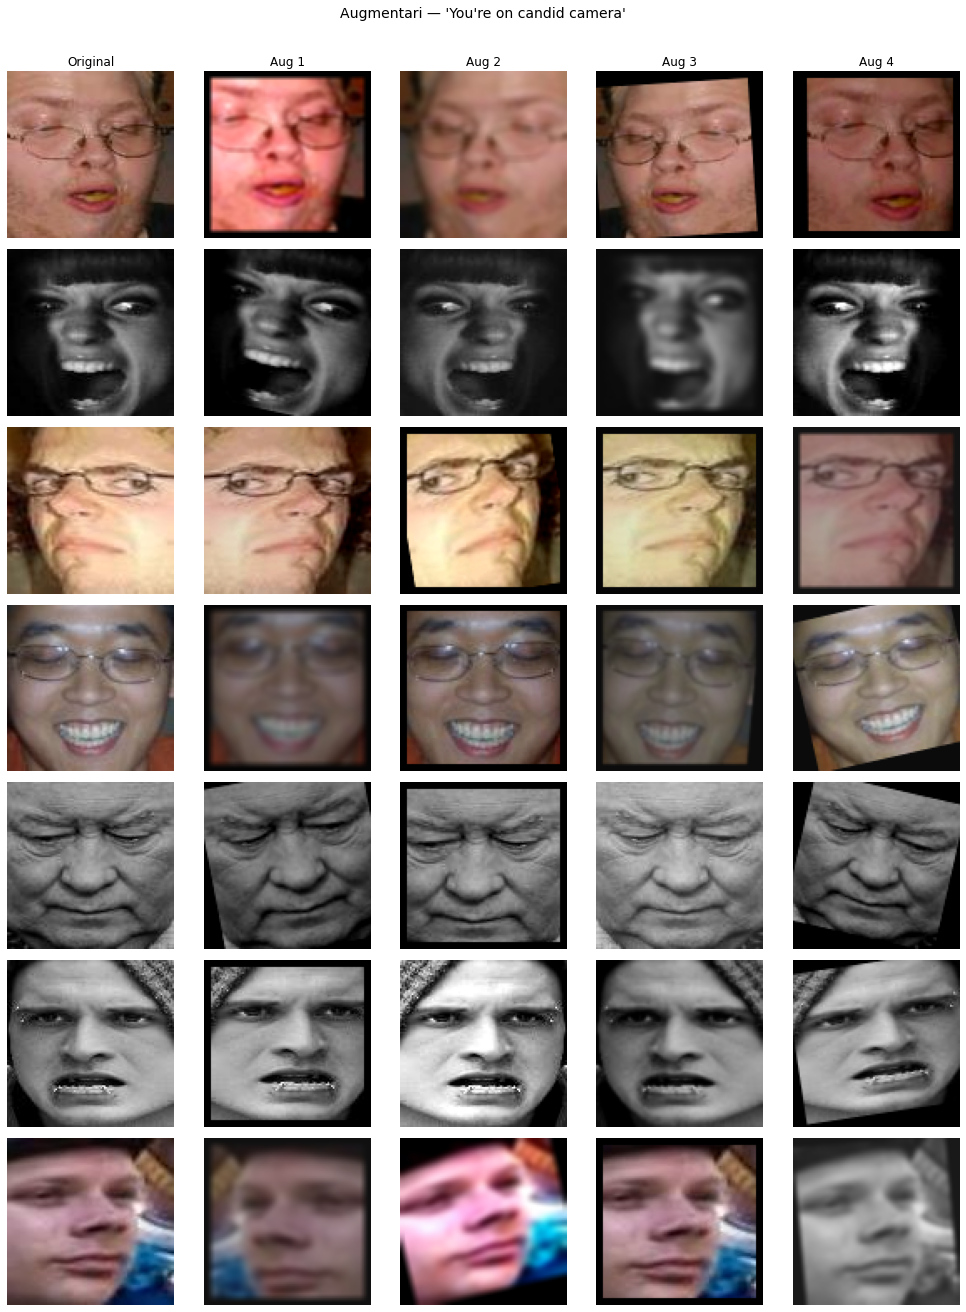

In [9]:
face_df_vis = pd.read_csv(FACE_DIR / 'splits' / 'train.csv')

fig, axes = plt.subplots(7, N_AUG + 1, figsize=(14, 18))
fig.suptitle("Augmentari — 'You're on candid camera'", fontsize=14, y=1.01)
for row, cls_name in enumerate(FaceDataset.CLASS_NAMES):
	sample = face_df_vis[face_df_vis['label'] == row + 1].iloc[0]
	img_orig = Image.open(FACE_DIR / sample['path']).convert('RGB')
	img_np = np.array(img_orig)
	axes[row, 0].imshow(img_orig)
	axes[row, 0].set_ylabel(cls_name, fontsize=10, fontweight='bold')
	axes[row, 0].set_title('Original' if row == 0 else '')
	axes[row, 0].axis('off')
	for col in range(1, N_AUG + 1):
		aug_img = face_aug_all(image=img_np)['image']
		axes[row, col].imshow(aug_img)
		axes[row, col].set_title(f'Aug {col}' if row == 0 else '')
		axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('figures/fig_02_aug_face.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 3.2 Arhitectura MLP
---

## Definirea arhitecturii


In [15]:
class MLP(nn.Module):
	def __init__(self, input_dim, num_classes, use_dropout=True):
		super().__init__()
		drop = lambda p: nn.Dropout(p) if use_dropout else nn.Identity()
		self.net = nn.Sequential(
			nn.Flatten(),
			nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ReLU(inplace=True), drop(0.4),
			nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True), drop(0.3),
			nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), drop(0.2),
			nn.Linear(256, num_classes),
		)
	def forward(self, x): return self.net(x)

MLP_INPUT_DIM = 3 * 64 * 64
NUM_EPOCHS_MLP = 20
BATCH_SIZE = 64

tmp = MLP(MLP_INPUT_DIM, 7).to(device)
print('MLP output:', tmp(torch.randn(4, 3, 64, 64).to(device)).shape)
print(f'Parametri: {sum(p.numel() for p in tmp.parameters() if p.requires_grad):,}')
del tmp

MLP output: torch.Size([4, 7])
Parametri: 13,245,447


## Antrenare MLP — Alunite

In [11]:
mlp_tf = transforms.Compose([
	transforms.Resize((64, 64)),
	transforms.ToTensor(),
	transforms.Normalize(MoleDataset.MEAN, MoleDataset.STD),
])

ds_tr_mole = MoleDataset(MOLE_DIR/'train.csv', MOLE_DIR/'train', mlp_tf)
ds_va_mole = MoleDataset(MOLE_DIR/'test.csv', MOLE_DIR/'test', mlp_tf)
ldr_tr_mole = make_loader(ds_tr_mole, BATCH_SIZE, shuffle=True, drop_last=True)
ldr_va_mole = make_loader(ds_va_mole, BATCH_SIZE, shuffle=False)

print(f'Mole train: {len(ds_tr_mole)} | val: {len(ds_va_mole)}')
counts_mole = np.bincount(ds_tr_mole.labels, minlength=7)
for cls, cnt in zip(MoleDataset.CLASS_NAMES, counts_mole):
	print(f'  {cls}: {cnt} ({cnt/len(ds_tr_mole)*100:.1f}%)')

Mole train: 6009 | val: 2003
  akiec: 196 (3.3%)
  bcc: 308 (5.1%)
  bkl: 660 (11.0%)
  df: 69 (1.1%)
  mel: 668 (11.1%)
  nv: 4023 (66.9%)
  vasc: 85 (1.4%)


In [12]:
set_seed()
mlp_mole = MLP(MLP_INPUT_DIM, 7, use_dropout=True).to(device)
opt_mlp_mole = optim.Adam(mlp_mole.parameters(), lr=1e-3, weight_decay=1e-4)
sch_mlp_mole = CosineAnnealingLR(opt_mlp_mole, T_max=NUM_EPOCHS_MLP)
rez_mlp_mole = train_model(
	mlp_mole, ldr_tr_mole, ldr_va_mole,
	nn.CrossEntropyLoss(), opt_mlp_mole, sch_mlp_mole,
	NUM_EPOCHS_MLP, device, run_name='mlp_mole'
)

torch.cuda.empty_cache()


Epoca 01/20 | train loss=1.0055 acc=0.640 | val loss=0.8756 acc=0.691 f1=0.2732
Epoca 02/20 | train loss=0.8496 acc=0.690 | val loss=0.8286 acc=0.708 f1=0.2785
Epoca 03/20 | train loss=0.8203 acc=0.704 | val loss=0.8069 acc=0.722 f1=0.3198
Epoca 04/20 | train loss=0.7949 acc=0.710 | val loss=0.8049 acc=0.709 f1=0.2953
Epoca 05/20 | train loss=0.7707 acc=0.720 | val loss=0.8217 acc=0.719 f1=0.3082
Epoca 06/20 | train loss=0.7372 acc=0.725 | val loss=0.7877 acc=0.728 f1=0.3355
Epoca 07/20 | train loss=0.7164 acc=0.735 | val loss=0.7853 acc=0.717 f1=0.3452
Epoca 08/20 | train loss=0.7009 acc=0.737 | val loss=0.7558 acc=0.729 f1=0.3521
Epoca 09/20 | train loss=0.6852 acc=0.738 | val loss=0.7535 acc=0.726 f1=0.3940
Epoca 10/20 | train loss=0.6613 acc=0.747 | val loss=0.7601 acc=0.728 f1=0.3604
Epoca 11/20 | train loss=0.6365 acc=0.762 | val loss=0.7502 acc=0.733 f1=0.3941
Epoca 12/20 | train loss=0.6182 acc=0.764 | val loss=0.7688 acc=0.728 f1=0.3838
Epoca 13/20 | train loss=0.5985 acc=0.77

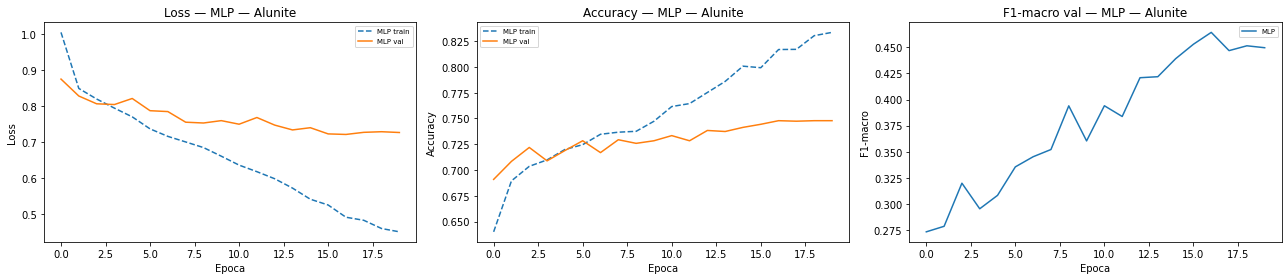

In [13]:
plot_history({'MLP': rez_mlp_mole}, 'MLP — Alunite',
	save_path='figures/fig_03_mlp_mole_history.png')

=== MLP — Alunite (val) ===
Accuracy : 0.7479
F1-macro : 0.4644
F1-micro : 0.7479
              precision    recall  f1-score   support

       akiec       0.45      0.35      0.40        65
         bcc       0.58      0.50      0.54       103
         bkl       0.48      0.49      0.48       220
          df       0.20      0.04      0.07        23
         mel       0.49      0.32      0.38       222
          nv       0.84      0.92      0.88      1341
        vasc       0.63      0.41      0.50        29

    accuracy                           0.75      2003
   macro avg       0.52      0.43      0.46      2003
weighted avg       0.72      0.75      0.73      2003



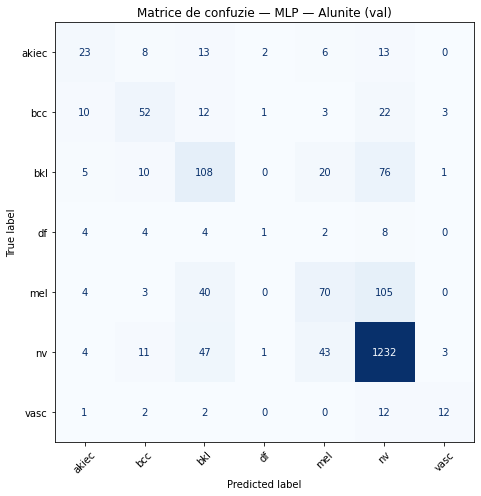

In [14]:
mlp_mole.load_state_dict(torch.load('checkpoints/mlp_mole_best.pt',
	map_location=device, weights_only=True))
metrici_mlp_mole = compute_metrics(
	mlp_mole, ldr_va_mole, device, MoleDataset.CLASS_NAMES,
	title='MLP — Alunite (val)', save_path='figures/fig_04_mlp_mole_cm.png'
)

## Antrenare MLP — Expresii faciale

In [15]:
face_tf = transforms.Compose([
	transforms.Resize((64, 64)),
	transforms.ToTensor(),
	transforms.Normalize(FACE_MEAN, FACE_STD),
])

ds_tr_face = FaceDataset(FACE_DIR/'splits'/'train.csv', FACE_DIR, face_tf)
ds_va_face = FaceDataset(FACE_DIR/'splits'/'local_test.csv', FACE_DIR, face_tf)
ldr_tr_face = make_loader(ds_tr_face, BATCH_SIZE, shuffle=True, drop_last=True)
ldr_va_face = make_loader(ds_va_face, BATCH_SIZE, shuffle=False)

print(f'Face train: {len(ds_tr_face)} | val: {len(ds_va_face)}')
counts_face = np.bincount(ds_tr_face.labels, minlength=7)
for cls, cnt in zip(FaceDataset.CLASS_NAMES, counts_face):
	print(f'  {cls}: {cnt} ({cnt/len(ds_tr_face)*100:.1f}%)')

Face train: 10434 | val: 1837
  Surprise: 1097 (10.5%)
  Fear: 239 (2.3%)
  Disgust: 610 (5.8%)
  Happiness: 4057 (38.9%)
  Sadness: 1685 (16.1%)
  Anger: 600 (5.8%)
  Neutral: 2146 (20.6%)


In [16]:
set_seed()
mlp_face = MLP(MLP_INPUT_DIM, 7, use_dropout=True).to(device)
opt_mlp_face = optim.Adam(mlp_face.parameters(), lr=1e-3, weight_decay=1e-4)
sch_mlp_face = CosineAnnealingLR(opt_mlp_face, T_max=NUM_EPOCHS_MLP)
rez_mlp_face = train_model(
	mlp_face, ldr_tr_face, ldr_va_face,
	nn.CrossEntropyLoss(), opt_mlp_face, sch_mlp_face,
	NUM_EPOCHS_MLP, device, run_name='mlp_face'
)

torch.cuda.empty_cache()


Epoca 01/20 | train loss=1.4139 acc=0.484 | val loss=1.2408 acc=0.545 f1=0.3167
Epoca 02/20 | train loss=1.1710 acc=0.579 | val loss=1.1067 acc=0.604 f1=0.4195
Epoca 03/20 | train loss=1.0767 acc=0.612 | val loss=1.0654 acc=0.621 f1=0.4575
Epoca 04/20 | train loss=1.0201 acc=0.636 | val loss=1.0472 acc=0.633 f1=0.5006
Epoca 05/20 | train loss=0.9824 acc=0.647 | val loss=1.0419 acc=0.634 f1=0.4860
Epoca 06/20 | train loss=0.9492 acc=0.664 | val loss=1.0621 acc=0.629 f1=0.4666
Epoca 07/20 | train loss=0.9151 acc=0.673 | val loss=0.9898 acc=0.648 f1=0.4925
Epoca 08/20 | train loss=0.8954 acc=0.680 | val loss=0.9868 acc=0.662 f1=0.5031
Epoca 09/20 | train loss=0.8621 acc=0.691 | val loss=0.9653 acc=0.664 f1=0.5218
Epoca 10/20 | train loss=0.8242 acc=0.704 | val loss=0.9616 acc=0.665 f1=0.5183
Epoca 11/20 | train loss=0.8011 acc=0.713 | val loss=0.9567 acc=0.662 f1=0.5352
Epoca 12/20 | train loss=0.7633 acc=0.725 | val loss=0.9658 acc=0.672 f1=0.5348
Epoca 13/20 | train loss=0.7349 acc=0.73

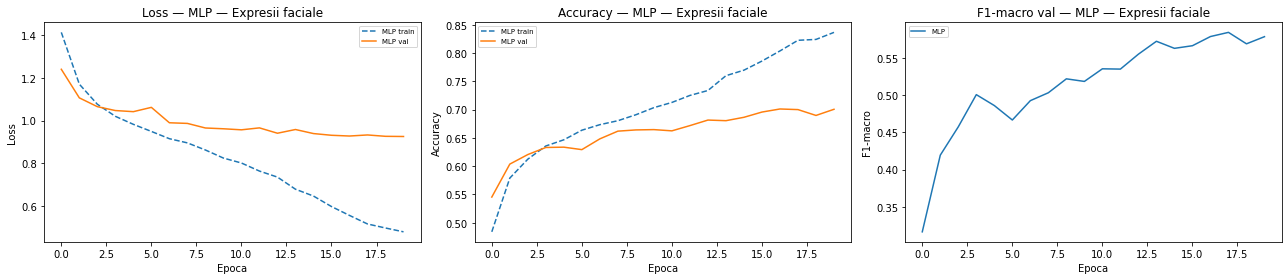

In [17]:
plot_history({'MLP': rez_mlp_face}, 'MLP — Expresii faciale',
	save_path='figures/fig_05_mlp_face_history.png')

=== MLP — Expresii faciale (val) ===
Accuracy : 0.7001
F1-macro : 0.5840
F1-micro : 0.7001
              precision    recall  f1-score   support

    Surprise       0.70      0.71      0.70       193
        Fear       0.58      0.26      0.36        42
     Disgust       0.46      0.36      0.41       107
   Happiness       0.83      0.87      0.85       715
     Sadness       0.58      0.58      0.58       297
       Anger       0.64      0.47      0.54       105
     Neutral       0.62      0.68      0.65       378

    accuracy                           0.70      1837
   macro avg       0.63      0.56      0.58      1837
weighted avg       0.69      0.70      0.69      1837



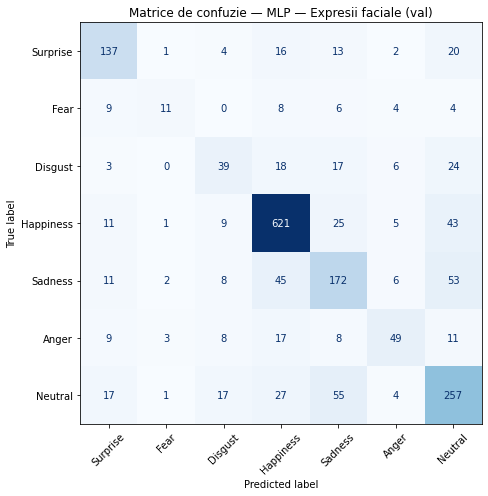

In [18]:
mlp_face.load_state_dict(torch.load('checkpoints/mlp_face_best.pt',
	map_location=device, weights_only=True))
metrici_mlp_face = compute_metrics(
	mlp_face, ldr_va_face, device, FaceDataset.CLASS_NAMES,
	title='MLP — Expresii faciale (val)', save_path='figures/fig_06_mlp_face_cm.png'
)

---
# 3.3 Arhitectura CNN
---

## Definirea arhitecturii CNN comune


In [11]:
class CNN(nn.Module):
	def __init__(self, num_classes, first_kernel=3, use_bn=True):
		super().__init__()
		p0 = first_kernel // 2

		def blk(in_c, out_c, k=3):
			layers = [nn.Conv2d(in_c, out_c, k, padding=k//2, bias=not use_bn)]
			if use_bn: layers.append(nn.BatchNorm2d(out_c))
			layers += [nn.ReLU(inplace=True), nn.MaxPool2d(2)]
			return nn.Sequential(*layers)

		self.features = nn.Sequential(
			nn.Conv2d(3, 32, first_kernel, padding=p0, bias=not use_bn),
			nn.BatchNorm2d(32) if use_bn else nn.Identity(),
			nn.ReLU(inplace=True), nn.MaxPool2d(2),
			blk(32, 64),
			blk(64, 128),
			nn.Conv2d(128, 256, 3, padding=1, bias=not use_bn),
			nn.BatchNorm2d(256) if use_bn else nn.Identity(),
			nn.ReLU(inplace=True),
			nn.AdaptiveAvgPool2d(1),
		)
		self.classifier = nn.Sequential(
			nn.Flatten(),
			nn.Dropout(0.5),
			nn.Linear(256, 128), nn.ReLU(inplace=True),
			nn.Dropout(0.3),
			nn.Linear(128, num_classes),
		)

	def forward(self, x): return self.classifier(self.features(x))

NUM_EPOCHS_CNN = 20

tmp = CNN(7, first_kernel=3).to(device)
print('CNN output:', tmp(torch.randn(4, 3, 96, 96).to(device)).shape)
print(f'Parametri: {sum(p.numel() for p in tmp.parameters() if p.requires_grad):,}')
del tmp

CNN output: torch.Size([4, 7])
Parametri: 422,695


## Antrenare CNN — Alunite


In [20]:
ds_tr_mole_cnn = MoleDataset(MOLE_DIR/'train.csv', MOLE_DIR/'train',
	make_mole_transform(aug=mole_aug_all, img_size=96))
ds_va_mole_cnn = MoleDataset(MOLE_DIR/'test.csv', MOLE_DIR/'test',
	make_mole_transform(aug=None, img_size=96))
ldr_tr_mole_cnn = make_loader(ds_tr_mole_cnn, BATCH_SIZE, shuffle=True, drop_last=True)
ldr_va_mole_cnn = make_loader(ds_va_mole_cnn, BATCH_SIZE, shuffle=False)

set_seed()
cnn_mole = CNN(num_classes=7, first_kernel=5, use_bn=True).to(device)
opt_cnn_mole = optim.Adam(cnn_mole.parameters(), lr=1e-3, weight_decay=1e-4)
sch_cnn_mole = CosineAnnealingLR(opt_cnn_mole, T_max=NUM_EPOCHS_CNN)
rez_cnn_mole = train_model(
	cnn_mole, ldr_tr_mole_cnn, ldr_va_mole_cnn,
	nn.CrossEntropyLoss(), opt_cnn_mole, sch_cnn_mole,
	NUM_EPOCHS_CNN, device, run_name='cnn_mole'
)

torch.cuda.empty_cache()


Epoca 01/20 | train loss=1.0598 acc=0.644 | val loss=0.9294 acc=0.669 f1=0.1146
Epoca 02/20 | train loss=0.9475 acc=0.669 | val loss=0.8967 acc=0.674 f1=0.1293
Epoca 03/20 | train loss=0.9122 acc=0.679 | val loss=0.9872 acc=0.596 f1=0.2412
Epoca 04/20 | train loss=0.8784 acc=0.685 | val loss=0.8317 acc=0.696 f1=0.2662
Epoca 05/20 | train loss=0.8667 acc=0.691 | val loss=0.8229 acc=0.708 f1=0.2993
Epoca 06/20 | train loss=0.8430 acc=0.697 | val loss=0.8007 acc=0.703 f1=0.2752
Epoca 07/20 | train loss=0.8307 acc=0.697 | val loss=0.7915 acc=0.696 f1=0.3104
Epoca 08/20 | train loss=0.8307 acc=0.696 | val loss=0.7981 acc=0.697 f1=0.2696
Epoca 09/20 | train loss=0.8245 acc=0.699 | val loss=0.8004 acc=0.713 f1=0.2851
Epoca 10/20 | train loss=0.8182 acc=0.700 | val loss=0.7713 acc=0.710 f1=0.3035
Epoca 11/20 | train loss=0.7993 acc=0.706 | val loss=0.7586 acc=0.713 f1=0.2978
Epoca 12/20 | train loss=0.7859 acc=0.707 | val loss=0.7515 acc=0.723 f1=0.3211
Epoca 13/20 | train loss=0.7857 acc=0.71

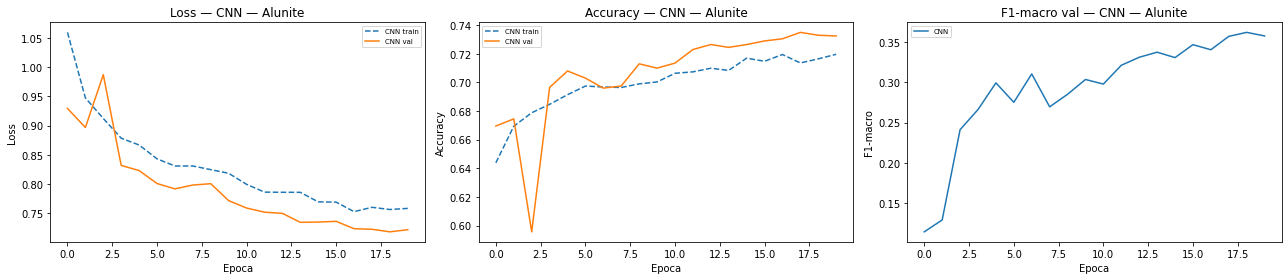

In [21]:
plot_history({'CNN': rez_cnn_mole}, 'CNN — Alunite',
	save_path='figures/fig_07_cnn_mole_history.png')

=== CNN — Alunite (val) ===
Accuracy : 0.7329
F1-macro : 0.3619
F1-micro : 0.7329
              precision    recall  f1-score   support

       akiec       0.37      0.32      0.34        65
         bcc       0.45      0.36      0.40       103
         bkl       0.44      0.39      0.41       220
          df       0.00      0.00      0.00        23
         mel       0.52      0.30      0.38       222
          nv       0.82      0.94      0.87      1341
        vasc       0.67      0.07      0.12        29

    accuracy                           0.73      2003
   macro avg       0.46      0.34      0.36      2003
weighted avg       0.70      0.73      0.71      2003



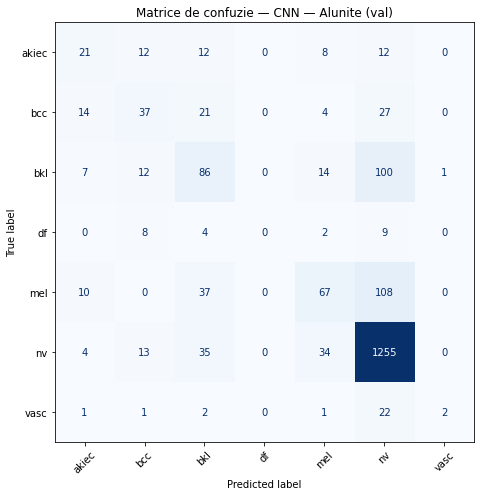

In [22]:
cnn_mole.load_state_dict(torch.load('checkpoints/cnn_mole_best.pt',
	map_location=device, weights_only=True))
metrici_cnn_mole = compute_metrics(
	cnn_mole, ldr_va_mole_cnn, device, MoleDataset.CLASS_NAMES,
	title='CNN — Alunite (val)', save_path='figures/fig_08_cnn_mole_cm.png'
)

## Antrenare CNN — Expresii faciale


In [23]:
ds_tr_face_cnn = FaceDataset(FACE_DIR/'splits'/'train.csv', FACE_DIR,
	make_face_transform(aug=face_aug_all, img_size=96))
ds_va_face_cnn = FaceDataset(FACE_DIR/'splits'/'local_test.csv', FACE_DIR,
	make_face_transform(aug=None, img_size=96))
ldr_tr_face_cnn = make_loader(ds_tr_face_cnn, BATCH_SIZE, shuffle=True, drop_last=True)
ldr_va_face_cnn = make_loader(ds_va_face_cnn, BATCH_SIZE, shuffle=False)

set_seed()
cnn_face = CNN(num_classes=7, first_kernel=3, use_bn=True).to(device)
opt_cnn_face = optim.Adam(cnn_face.parameters(), lr=1e-3, weight_decay=1e-4)
sch_cnn_face = CosineAnnealingLR(opt_cnn_face, T_max=NUM_EPOCHS_CNN)
rez_cnn_face = train_model(
	cnn_face, ldr_tr_face_cnn, ldr_va_face_cnn,
	nn.CrossEntropyLoss(), opt_cnn_face, sch_cnn_face,
	NUM_EPOCHS_CNN, device, run_name='cnn_face'
)

torch.cuda.empty_cache()


Epoca 01/20 | train loss=1.6403 acc=0.385 | val loss=1.5969 acc=0.391 f1=0.0945
Epoca 02/20 | train loss=1.6069 acc=0.392 | val loss=1.5966 acc=0.400 f1=0.1163
Epoca 03/20 | train loss=1.6000 acc=0.396 | val loss=1.5839 acc=0.400 f1=0.1254
Epoca 04/20 | train loss=1.5943 acc=0.400 | val loss=1.5739 acc=0.395 f1=0.1099
Epoca 05/20 | train loss=1.5803 acc=0.399 | val loss=1.5705 acc=0.409 f1=0.1346
Epoca 06/20 | train loss=1.5689 acc=0.408 | val loss=1.5421 acc=0.405 f1=0.1396
Epoca 07/20 | train loss=1.5576 acc=0.406 | val loss=1.5281 acc=0.408 f1=0.1642
Epoca 08/20 | train loss=1.5360 acc=0.414 | val loss=1.5063 acc=0.419 f1=0.1586
Epoca 09/20 | train loss=1.5189 acc=0.427 | val loss=1.4578 acc=0.452 f1=0.2012
Epoca 10/20 | train loss=1.4816 acc=0.443 | val loss=1.4091 acc=0.479 f1=0.2425
Epoca 11/20 | train loss=1.4391 acc=0.464 | val loss=1.4626 acc=0.451 f1=0.2554
Epoca 12/20 | train loss=1.3954 acc=0.484 | val loss=1.3682 acc=0.481 f1=0.2880
Epoca 13/20 | train loss=1.3518 acc=0.50

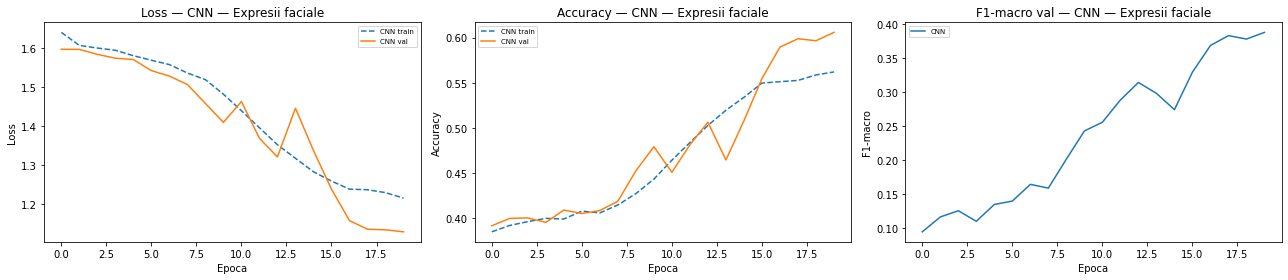

In [24]:
plot_history({'CNN': rez_cnn_face}, 'CNN — Expresii faciale',
	save_path='figures/fig_09_cnn_face_history.png')

=== CNN — Expresii faciale (val) ===
Accuracy : 0.6059
F1-macro : 0.3873
F1-micro : 0.6059
              precision    recall  f1-score   support

    Surprise       0.59      0.64      0.62       193
        Fear       0.00      0.00      0.00        42
     Disgust       0.00      0.00      0.00       107
   Happiness       0.74      0.83      0.78       715
     Sadness       0.44      0.33      0.37       297
       Anger       0.43      0.30      0.35       105
     Neutral       0.50      0.71      0.59       378

    accuracy                           0.61      1837
   macro avg       0.39      0.40      0.39      1837
weighted avg       0.55      0.61      0.57      1837



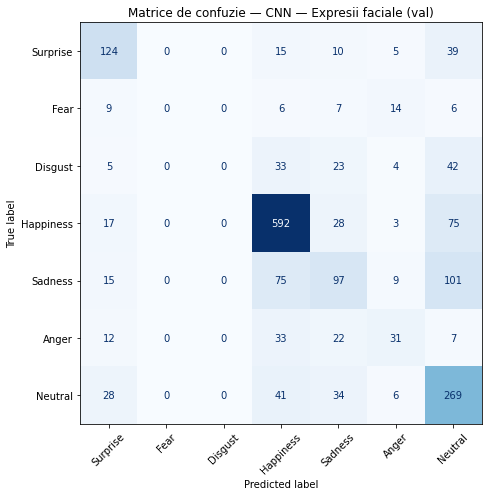

In [25]:
cnn_face.load_state_dict(torch.load('checkpoints/cnn_face_best.pt',
	map_location=device, weights_only=True))
metrici_cnn_face = compute_metrics(
	cnn_face, ldr_va_face_cnn, device, FaceDataset.CLASS_NAMES,
	title='CNN — Expresii faciale (val)', save_path='figures/fig_10_cnn_face_cm.png'
)

---
# 3.4 Fine-tuning ResNet-18
---

In [26]:
def build_resnet18(num_classes):
	model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
	for p in model.parameters(): p.requires_grad = False
	for p in model.layer3.parameters(): p.requires_grad = True
	for p in model.layer4.parameters(): p.requires_grad = True
	model.fc = nn.Sequential(
		nn.Dropout(0.5),
		nn.Linear(512, num_classes)
	)
	return model

def make_warmup_cosine(optimizer, warmup_epochs, total_epochs):
	warmup = LambdaLR(optimizer, lr_lambda=lambda e: (e + 1) / warmup_epochs)
	cosine = CosineAnnealingLR(optimizer, T_max=total_epochs - warmup_epochs)
	return SequentialLR(optimizer, schedulers=[warmup, cosine],
							milestones=[warmup_epochs])

NUM_EPOCHS_FT = 40
WARMUP_EPOCHS = 3
IMG_SIZE_FT = 224
BATCH_SIZE_FT = 32
print(f'Fine-tuning: img={IMG_SIZE_FT}px, epoci={NUM_EPOCHS_FT}, warmup={WARMUP_EPOCHS}ep')

Fine-tuning: img=224px, epoci=40, warmup=3ep


## Fine-tuning ResNet-18 — Alunite

In [27]:
ds_tr_mole_ft = MoleDataset(MOLE_DIR/'train.csv', MOLE_DIR/'train',
	make_mole_transform(aug=mole_aug_all, img_size=IMG_SIZE_FT, finetune=True))
ds_va_mole_ft = MoleDataset(MOLE_DIR/'test.csv', MOLE_DIR/'test',
	make_mole_transform(aug=None, img_size=IMG_SIZE_FT, finetune=True))

ldr_tr_mole_ft = make_loader(ds_tr_mole_ft, BATCH_SIZE_FT,
											shuffle=True, drop_last=True)
ldr_va_mole_ft = make_loader(ds_va_mole_ft, BATCH_SIZE_FT, shuffle=False)

criterion_ft_mole = nn.CrossEntropyLoss(weight=get_class_weights(ds_tr_mole_ft, 7, device))

set_seed()
resnet_mole = build_resnet18(num_classes=7).to(device)
opt_ft_mole = optim.Adam([
	{'params': resnet_mole.layer3.parameters(), 'lr': 1e-5},
	{'params': resnet_mole.layer4.parameters(), 'lr': 1e-4},
	{'params': resnet_mole.fc.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
sch_ft_mole = make_warmup_cosine(opt_ft_mole, WARMUP_EPOCHS, NUM_EPOCHS_FT)

rez_ft_mole = train_model(
	resnet_mole, ldr_tr_mole_ft, ldr_va_mole_ft,
	criterion_ft_mole, opt_ft_mole, sch_ft_mole,
	NUM_EPOCHS_FT, device, run_name='ft_mole'
)
torch.cuda.empty_cache()

Epoca 01/40 | train loss=1.7719 acc=0.411 | val loss=1.2674 acc=0.646 f1=0.4728
Epoca 02/40 | train loss=1.2993 acc=0.566 | val loss=0.9935 acc=0.666 f1=0.5411
Epoca 03/40 | train loss=1.1123 acc=0.603 | val loss=0.9128 acc=0.643 f1=0.5406
Epoca 04/40 | train loss=1.0266 acc=0.613 | val loss=0.9316 acc=0.672 f1=0.5698
Epoca 05/40 | train loss=0.9916 acc=0.626 | val loss=0.8907 acc=0.722 f1=0.5885
Epoca 06/40 | train loss=0.9379 acc=0.649 | val loss=0.8774 acc=0.676 f1=0.6057
Epoca 07/40 | train loss=0.8520 acc=0.642 | val loss=0.9881 acc=0.711 f1=0.5967
Epoca 08/40 | train loss=0.8796 acc=0.662 | val loss=0.9196 acc=0.706 f1=0.5409
Epoca 09/40 | train loss=0.7927 acc=0.659 | val loss=0.9060 acc=0.687 f1=0.6122
Epoca 10/40 | train loss=0.7922 acc=0.661 | val loss=0.8923 acc=0.691 f1=0.5873
Epoca 11/40 | train loss=0.7947 acc=0.673 | val loss=0.9114 acc=0.637 f1=0.5555
Epoca 12/40 | train loss=0.7545 acc=0.678 | val loss=0.9209 acc=0.716 f1=0.6029
Epoca 13/40 | train loss=0.7298 acc=0.68

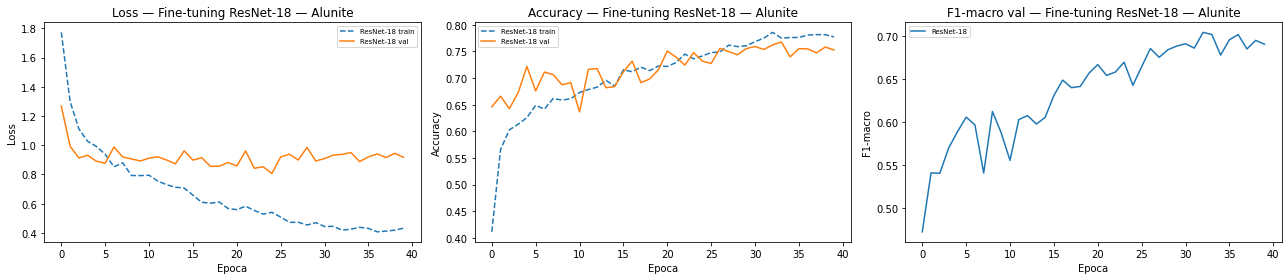

In [28]:
plot_history({'ResNet-18': rez_ft_mole}, 'Fine-tuning ResNet-18 — Alunite',
	save_path='figures/fig_11_ft_mole_history.png')


=== ResNet-18 — Alunite (val) ===
Accuracy : 0.7624
F1-macro : 0.7039
F1-micro : 0.7624
              precision    recall  f1-score   support

       akiec       0.57      0.62      0.59        65
         bcc       0.66      0.83      0.74       103
         bkl       0.56      0.70      0.62       220
          df       0.71      0.74      0.72        23
         mel       0.40      0.65      0.50       222
          nv       0.95      0.79      0.86      1341
        vasc       0.90      0.90      0.90        29

    accuracy                           0.76      2003
   macro avg       0.68      0.75      0.70      2003
weighted avg       0.82      0.76      0.78      2003



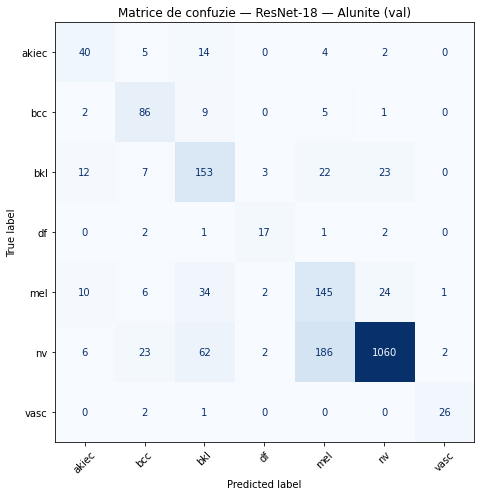

In [29]:
resnet_mole.load_state_dict(torch.load('checkpoints/ft_mole_best.pt',
	map_location=device, weights_only=True))
metrici_ft_mole = compute_metrics(
	resnet_mole, ldr_va_mole_ft, device, MoleDataset.CLASS_NAMES,
	title='ResNet-18 — Alunite (val)', save_path='figures/fig_12_ft_mole_cm.png'
)


## Fine-tuning ResNet-18 — Expresii faciale

In [30]:
ds_tr_face_ft = FaceDataset(FACE_DIR/'splits'/'train.csv', FACE_DIR,
	make_face_transform(aug=face_aug_all, img_size=IMG_SIZE_FT, finetune=True))
ds_va_face_ft = FaceDataset(FACE_DIR/'splits'/'local_test.csv', FACE_DIR,
	make_face_transform(aug=None, img_size=IMG_SIZE_FT, finetune=True))

ldr_tr_face_ft = make_loader(ds_tr_face_ft, BATCH_SIZE_FT,
											shuffle=True, drop_last=True)
ldr_va_face_ft = make_loader(ds_va_face_ft, BATCH_SIZE_FT, shuffle=False)

criterion_ft_face = nn.CrossEntropyLoss(weight=get_class_weights(ds_tr_face_ft, 7, device))

set_seed()
resnet_face = build_resnet18(num_classes=7).to(device)
opt_ft_face = optim.Adam([
	{'params': resnet_face.layer3.parameters(), 'lr': 1e-5},
	{'params': resnet_face.layer4.parameters(), 'lr': 1e-4},
	{'params': resnet_face.fc.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)
sch_ft_face = make_warmup_cosine(opt_ft_face, WARMUP_EPOCHS, NUM_EPOCHS_FT)

rez_ft_face = train_model(
	resnet_face, ldr_tr_face_ft, ldr_va_face_ft,
	criterion_ft_face, opt_ft_face, sch_ft_face,
	NUM_EPOCHS_FT, device, run_name='ft_face'
)
torch.cuda.empty_cache()

Epoca 01/40 | train loss=1.8019 acc=0.308 | val loss=1.4442 acc=0.458 f1=0.3905
Epoca 02/40 | train loss=1.4443 acc=0.488 | val loss=1.1673 acc=0.576 f1=0.5150
Epoca 03/40 | train loss=1.2567 acc=0.571 | val loss=0.9885 acc=0.627 f1=0.5646
Epoca 04/40 | train loss=1.0779 acc=0.637 | val loss=0.8515 acc=0.694 f1=0.6049
Epoca 05/40 | train loss=0.9793 acc=0.658 | val loss=0.8750 acc=0.693 f1=0.6037
Epoca 06/40 | train loss=0.9038 acc=0.689 | val loss=0.8937 acc=0.679 f1=0.5851
Epoca 07/40 | train loss=0.8315 acc=0.704 | val loss=0.8725 acc=0.682 f1=0.6145
Epoca 08/40 | train loss=0.8012 acc=0.713 | val loss=0.7019 acc=0.761 f1=0.6647
Epoca 09/40 | train loss=0.7058 acc=0.742 | val loss=0.9975 acc=0.656 f1=0.5899
Epoca 10/40 | train loss=0.6629 acc=0.756 | val loss=0.7409 acc=0.753 f1=0.6603
Epoca 11/40 | train loss=0.6448 acc=0.765 | val loss=0.7528 acc=0.756 f1=0.6777
Epoca 12/40 | train loss=0.5785 acc=0.779 | val loss=0.7570 acc=0.753 f1=0.6775
Epoca 13/40 | train loss=0.5668 acc=0.78

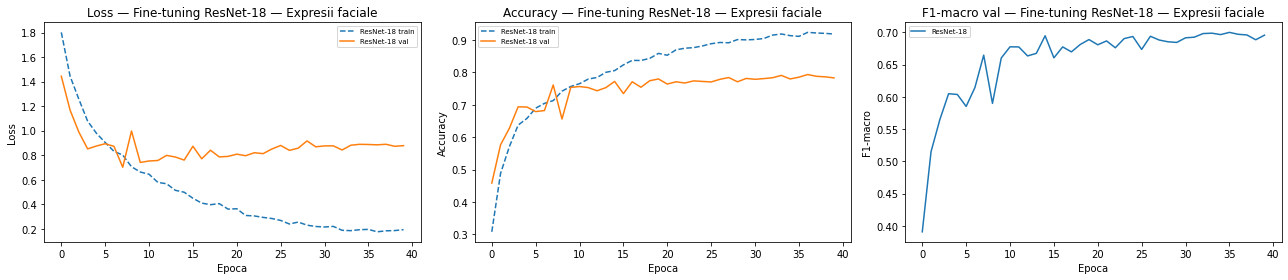

In [31]:
plot_history({'ResNet-18': rez_ft_face}, 'Fine-tuning ResNet-18 — Expresii faciale',
	save_path='figures/fig_13_ft_face_history.png')


=== ResNet-18 — Expresii faciale (val) ===
Accuracy : 0.7850
F1-macro : 0.7001
F1-micro : 0.7850
              precision    recall  f1-score   support

    Surprise       0.81      0.82      0.82       193
        Fear       0.63      0.40      0.49        42
     Disgust       0.53      0.46      0.49       107
   Happiness       0.93      0.85      0.89       715
     Sadness       0.73      0.77      0.75       297
       Anger       0.71      0.75      0.73       105
     Neutral       0.68      0.79      0.73       378

    accuracy                           0.78      1837
   macro avg       0.72      0.69      0.70      1837
weighted avg       0.79      0.78      0.79      1837



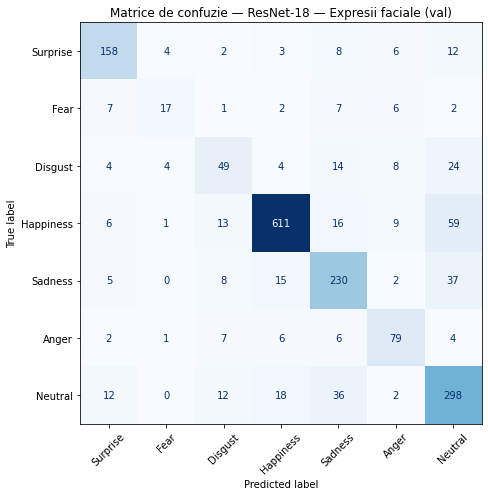

In [32]:
resnet_face.load_state_dict(torch.load('checkpoints/ft_face_best.pt',
	map_location=device, weights_only=True))
metrici_ft_face = compute_metrics(
	resnet_face, ldr_va_face_ft, device, FaceDataset.CLASS_NAMES,
	title='ResNet-18 — Expresii faciale (val)', save_path='figures/fig_14_ft_face_cm.png'
)


---
# 3.5 Ablatii
---

## Ablatie MLP — cu / fara Dropout

In [33]:
def run_mlp(use_dropout, ds_name, tr_ldr, va_ldr):
	set_seed()
	model = MLP(MLP_INPUT_DIM, 7, use_dropout=use_dropout).to(device)
	opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	sch = CosineAnnealingLR(opt, T_max=NUM_EPOCHS_MLP)
	tag = 'cu_dropout' if use_dropout else 'fara_dropout'
	h = train_model(model, tr_ldr, va_ldr, nn.CrossEntropyLoss(), opt, sch,
		NUM_EPOCHS_MLP, device, f'abl_mlp_{ds_name}_{tag}', verbose=False)
	torch.cuda.empty_cache()
	return h, model

print('Ablatie MLP — Alunite (cu dropout):')
rez_mlp_mole_drop, mdl_mlp_mole_drop = run_mlp(True, 'mole', ldr_tr_mole, ldr_va_mole)
print('Ablatie MLP — Alunite (fara dropout):')
rez_mlp_mole_nodrop, _ = run_mlp(False, 'mole', ldr_tr_mole, ldr_va_mole)
print('Ablatie MLP — Fete (cu dropout):')
rez_mlp_face_drop, mdl_mlp_face_drop = run_mlp(True, 'face', ldr_tr_face, ldr_va_face)
print('Ablatie MLP — Fete (fara dropout):')
rez_mlp_face_nodrop, _ = run_mlp(False, 'face', ldr_tr_face, ldr_va_face)
print('Done')


Ablatie MLP — Alunite (cu dropout):
Ablatie MLP — Alunite (fara dropout):
Ablatie MLP — Fete (cu dropout):
Ablatie MLP — Fete (fara dropout):
Done


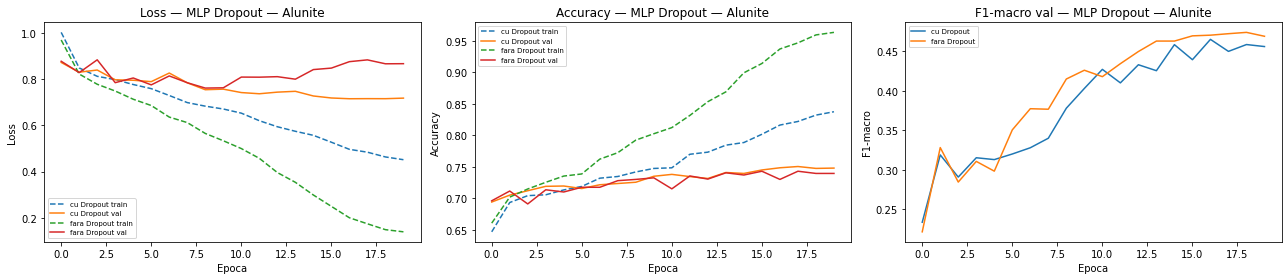

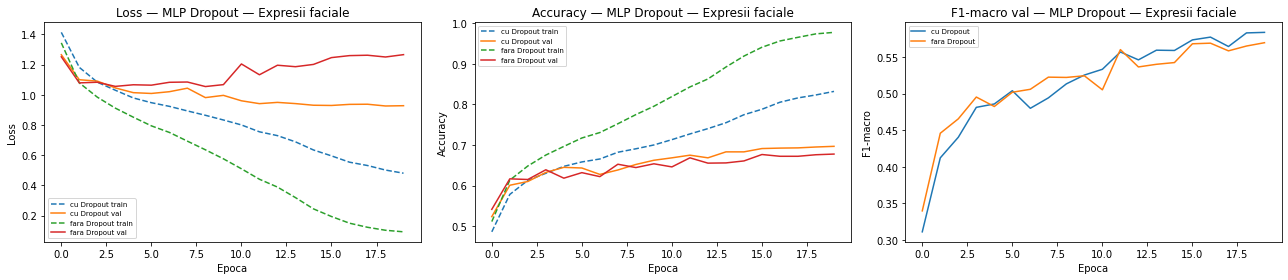

In [34]:
plot_history({'cu Dropout': rez_mlp_mole_drop, 'fara Dropout': rez_mlp_mole_nodrop},
	'MLP Dropout — Alunite', save_path='figures/fig_15_abl_mlp_mole_dropout.png')
plot_history({'cu Dropout': rez_mlp_face_drop, 'fara Dropout': rez_mlp_face_nodrop},
	'MLP Dropout — Expresii faciale', save_path='figures/fig_16_abl_mlp_face_dropout.png')

## Ablatie CNN — cu / fara BatchNorm

In [35]:
def run_cnn_bn(use_bn, fk, ds_name, tr_ldr, va_ldr):
	set_seed()
	model = CNN(7, first_kernel=fk, use_bn=use_bn).to(device)
	opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	sch = CosineAnnealingLR(opt, T_max=NUM_EPOCHS_CNN)
	tag = 'cu_bn' if use_bn else 'fara_bn'
	h = train_model(model, tr_ldr, va_ldr, nn.CrossEntropyLoss(), opt, sch,
		NUM_EPOCHS_CNN, device, f'abl_bn_{ds_name}_{tag}', verbose=False)
	torch.cuda.empty_cache()
	return h

print('Ablatie BN — Alunite:')
rez_cnn_mole_bn = run_cnn_bn(True, 5, 'mole', ldr_tr_mole_cnn, ldr_va_mole_cnn)
rez_cnn_mole_nobn = run_cnn_bn(False, 5, 'mole', ldr_tr_mole_cnn, ldr_va_mole_cnn)
print('Ablatie BN — Fete:')
rez_cnn_face_bn = run_cnn_bn(True, 3, 'face', ldr_tr_face_cnn, ldr_va_face_cnn)
rez_cnn_face_nobn = run_cnn_bn(False, 3, 'face', ldr_tr_face_cnn, ldr_va_face_cnn)
print('Done')


Ablatie BN — Alunite:
Ablatie BN — Fete:
Done


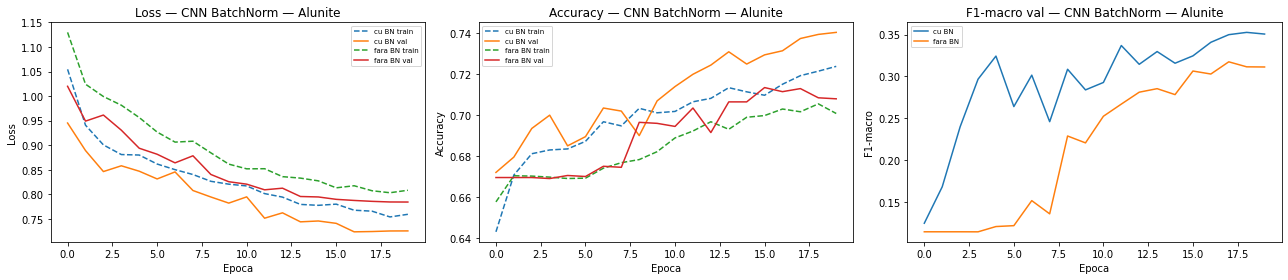

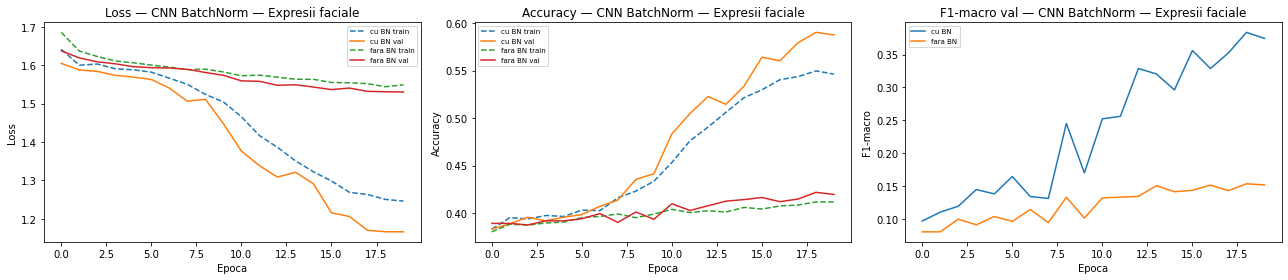

In [36]:
plot_history({'cu BN': rez_cnn_mole_bn, 'fara BN': rez_cnn_mole_nobn},
	'CNN BatchNorm — Alunite', save_path='figures/fig_17_abl_cnn_mole_bn.png')
plot_history({'cu BN': rez_cnn_face_bn, 'fara BN': rez_cnn_face_nobn},
	'CNN BatchNorm — Expresii faciale', save_path='figures/fig_18_abl_cnn_face_bn.png')

## Ablatie CNN — configuratii de augmentare


In [37]:
aug_cfgs_mole = {
	'Fara aug': None,
	'Geometrice': mole_aug_geometric,
	'Culori': mole_aug_color,
	'Toate': mole_aug_all,
}

rez_aug_mole = {}
for name, aug in aug_cfgs_mole.items():
	print(f'CNN mole aug={name} ...')
	ds_tr = MoleDataset(MOLE_DIR/'train.csv', MOLE_DIR/'train',
		make_mole_transform(aug=aug, img_size=96))
	ds_va = MoleDataset(MOLE_DIR/'test.csv', MOLE_DIR/'test',
		make_mole_transform(aug=None, img_size=96))
	ldr_tr = make_loader(ds_tr, BATCH_SIZE, shuffle=True, drop_last=True)
	ldr_va = make_loader(ds_va, BATCH_SIZE, shuffle=False)
	set_seed()
	model = CNN(7, first_kernel=5, use_bn=True).to(device)
	opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	sch = CosineAnnealingLR(opt, T_max=NUM_EPOCHS_CNN)
	histories_aug_mole[name] = train_model(
		model, ldr_tr, ldr_va, nn.CrossEntropyLoss(), opt, sch,
		NUM_EPOCHS_CNN, device, f'abl_aug_mole_{name.replace(" ","_")}',
		verbose=False)
	del model, opt, sch, ldr_tr, ldr_va, ds_tr, ds_va
	torch.cuda.empty_cache()
	print('Done')


CNN mole aug=Fara aug ...
Done
CNN mole aug=Geometrice ...
Done
CNN mole aug=Culori ...
Done
CNN mole aug=Toate ...
Done


In [38]:
aug_cfgs_face = {
	'Fara aug': None,
	'Geometrice': face_aug_geometric,
	'Culori': face_aug_color,
	'Toate': face_aug_all,
}

rez_aug_face = {}
for name, aug in aug_cfgs_face.items():
	print(f'CNN face aug={name} ...')
	ds_tr = FaceDataset(FACE_DIR/'splits'/'train.csv', FACE_DIR,
		make_face_transform(aug=aug, img_size=96))
	ds_va = FaceDataset(FACE_DIR/'splits'/'local_test.csv', FACE_DIR,
		make_face_transform(aug=None, img_size=96))
	ldr_tr = make_loader(ds_tr, BATCH_SIZE, shuffle=True, drop_last=True)
	ldr_va = make_loader(ds_va, BATCH_SIZE, shuffle=False)
	set_seed()
	model = CNN(7, first_kernel=3, use_bn=True).to(device)
	opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	sch = CosineAnnealingLR(opt, T_max=NUM_EPOCHS_CNN)
	histories_aug_face[name] = train_model(
		model, ldr_tr, ldr_va, nn.CrossEntropyLoss(), opt, sch,
		NUM_EPOCHS_CNN, device, f'abl_aug_face_{name.replace(" ","_")}',
		verbose=False)
	del model, opt, sch, ldr_tr, ldr_va, ds_tr, ds_va
	torch.cuda.empty_cache()
	print('Done')


CNN face aug=Fara aug ...
Done
CNN face aug=Geometrice ...
Done
CNN face aug=Culori ...
Done
CNN face aug=Toate ...
Done


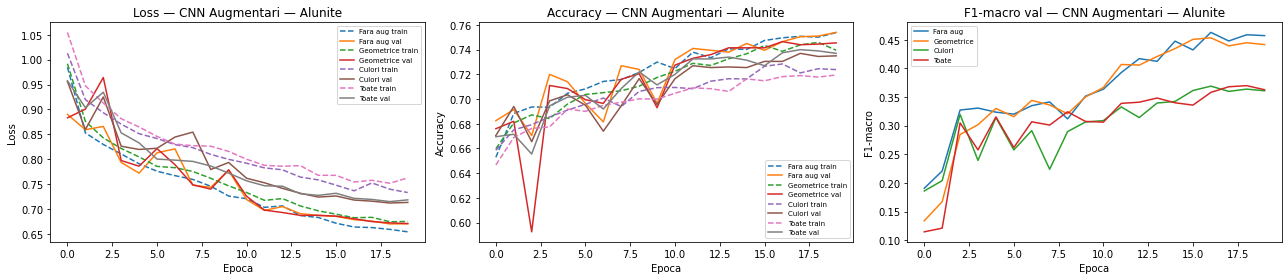

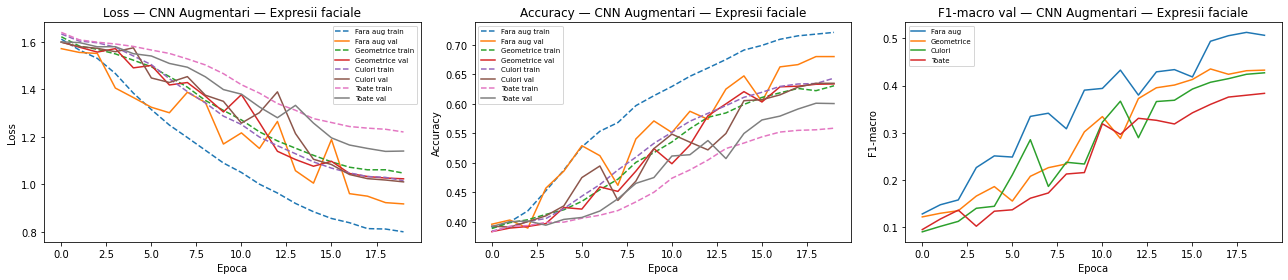

In [39]:
plot_history(rez_aug_mole, 'CNN Augmentari — Alunite',
	save_path='figures/fig_19_abl_cnn_mole_aug.png')
plot_history(rez_aug_face, 'CNN Augmentari — Expresii faciale',
	save_path='figures/fig_20_abl_cnn_face_aug.png')

## Ablatie — Tehnici de tratare a dezechilibrului de clase

In [40]:
def run_imbalance(ds_name, tr_ds, va_ds, fk, use_sampler, use_wloss):
	set_seed()
	model = CNN(7, first_kernel=fk, use_bn=True).to(device)
	opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	sch = CosineAnnealingLR(opt, T_max=NUM_EPOCHS_CNN)
	sampler = get_sampler(tr_ds, 7) if use_sampler else None
	ldr_tr = make_loader(tr_ds, BATCH_SIZE, shuffle=not use_sampler,
		drop_last=True, sampler=sampler)
	ldr_va = make_loader(va_ds, BATCH_SIZE, shuffle=False)
	criterion = (nn.CrossEntropyLoss(weight=get_class_weights(tr_ds, 7, device))
		if use_wloss else nn.CrossEntropyLoss())
	parts = []
	if use_sampler: parts.append('sampler')
	if use_wloss: parts.append('wloss')
	tag = '_'.join(parts) if parts else 'standard'
	h = train_model(model, ldr_tr, ldr_va, criterion, opt, sch,
		NUM_EPOCHS_CNN, device, f'abl_imbal_{ds_name}_{tag}', verbose=False)
	del model, opt, sch
	torch.cuda.empty_cache()
	return h

print('Ablatie dezechilibru — Alunite:')
rez_imb_mole_std = run_imbalance('mole', ds_tr_mole_cnn, ds_va_mole_cnn, 5, False, False)
rez_imb_mole_wloss = run_imbalance('mole', ds_tr_mole_cnn, ds_va_mole_cnn, 5, False, True)
rez_imb_mole_samp = run_imbalance('mole', ds_tr_mole_cnn, ds_va_mole_cnn, 5, True, False)
print('Ablatie dezechilibru — Fete:')
rez_imb_face_std = run_imbalance('face', ds_tr_face_cnn, ds_va_face_cnn, 3, False, False)
rez_imb_face_wloss = run_imbalance('face', ds_tr_face_cnn, ds_va_face_cnn, 3, False, True)
rez_imb_face_samp = run_imbalance('face', ds_tr_face_cnn, ds_va_face_cnn, 3, True, False)
print('Done')


Ablatie dezechilibru — Alunite:
Ablatie dezechilibru — Fete:
Done


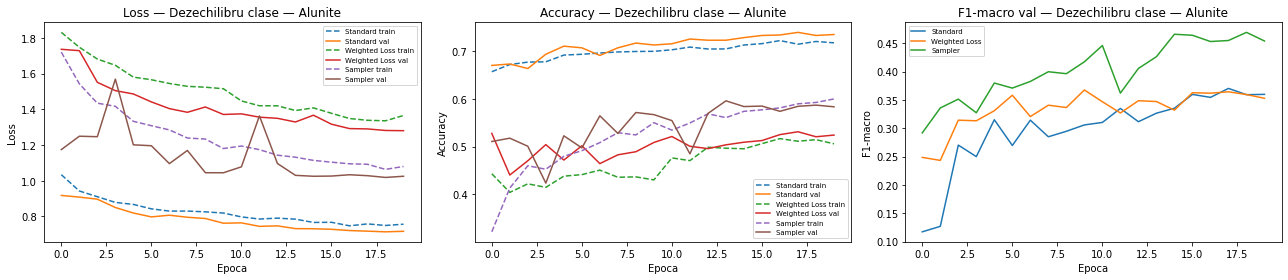

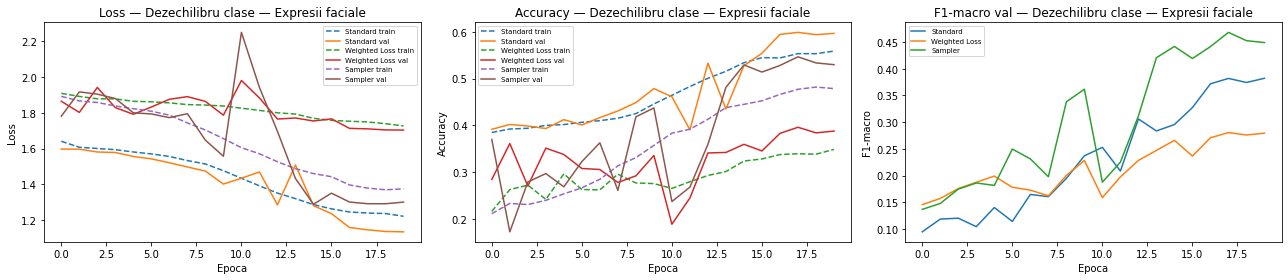

In [41]:
plot_history({'Standard': rez_imb_mole_std, 'Weighted Loss': rez_imb_mole_wloss, 'Sampler': rez_imb_mole_samp},
	'Dezechilibru clase — Alunite', save_path='figures/fig_21_abl_imbal_mole.png')
plot_history({'Standard': rez_imb_face_std, 'Weighted Loss': rez_imb_face_wloss, 'Sampler': rez_imb_face_samp},
	'Dezechilibru clase — Expresii faciale', save_path='figures/fig_22_abl_imbal_face.png')

## Ablatie — Fine-tuning cu / fara LR Warmup

In [42]:
def run_ft_warmup(ds_name, tr_ldr, va_ldr, criterion, use_warmup):
	set_seed()
	model = build_resnet18(num_classes=7).to(device)
	opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
		lr=1e-3, weight_decay=1e-4)
	sch = (make_warmup_cosine(opt, WARMUP_EPOCHS, NUM_EPOCHS_FT)
		if use_warmup else CosineAnnealingLR(opt, T_max=NUM_EPOCHS_FT))
	tag = 'cu_warmup' if use_warmup else 'fara_warmup'
	h = train_model(model, tr_ldr, va_ldr, criterion, opt, sch,
		NUM_EPOCHS_FT, device, f'abl_ft_{ds_name}_{tag}', verbose=False)
	del model, opt, sch
	torch.cuda.empty_cache()
	return h

print('Ablatie warmup — Alunite (cu warmup):')
rez_ft_mole_warmup = run_ft_warmup('mole', ldr_tr_mole_ft, ldr_va_mole_ft,
	criterion_ft_mole, True)
print('Ablatie warmup — Alunite (fara warmup):')
rez_ft_mole_no_warmup = run_ft_warmup('mole', ldr_tr_mole_ft, ldr_va_mole_ft,
	criterion_ft_mole, False)
print('Ablatie warmup — Fete (cu warmup):')
rez_ft_face_warmup = run_ft_warmup('face', ldr_tr_face_ft, ldr_va_face_ft,
	criterion_ft_face, True)
print('Ablatie warmup — Fete (fara warmup):')
rez_ft_face_no_warmup = run_ft_warmup('face', ldr_tr_face_ft, ldr_va_face_ft,
	criterion_ft_face, False)
print('Done')


Ablatie warmup — Alunite (cu warmup):
Ablatie warmup — Alunite (fara warmup):
Ablatie warmup — Fete (cu warmup):
Ablatie warmup — Fete (fara warmup):
Done


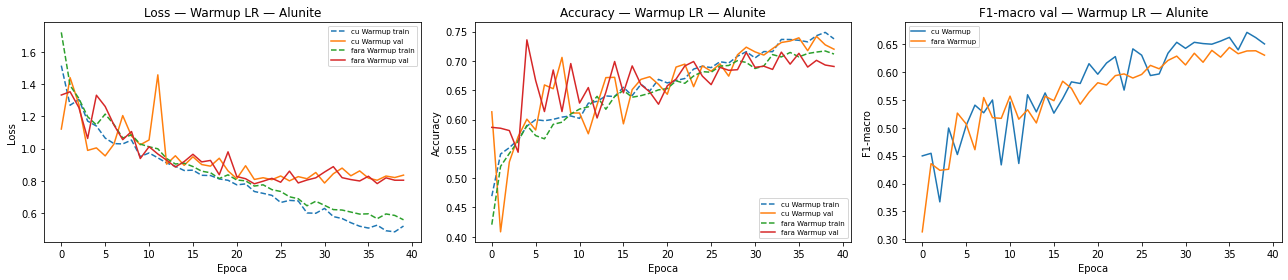

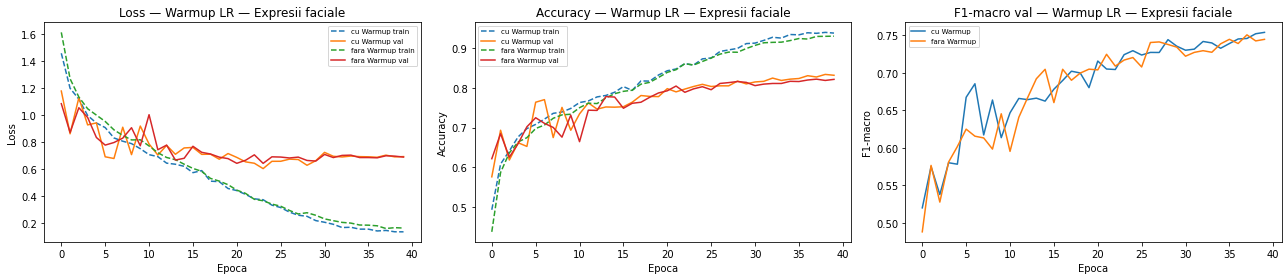

In [43]:
plot_history({'cu Warmup': rez_ft_mole_warmup, 'fara Warmup': rez_ft_mole_no_warmup},
	'Warmup LR — Alunite', save_path='figures/fig_23_abl_ft_mole_warmup.png')
plot_history({'cu Warmup': rez_ft_face_warmup, 'fara Warmup': rez_ft_face_no_warmup},
	'Warmup LR — Expresii faciale', save_path='figures/fig_24_abl_ft_face_warmup.png')

## Tabel comparativ — toate ablatiile

In [44]:
def best_acc(h): return round(max(h['val_acc']), 4)
def best_f1(h): return round(max(h['val_f1']), 4)

rows = [
	('MLP cu Dropout', 'Alunite', best_acc(rez_mlp_mole_drop), best_f1(rez_mlp_mole_drop)),
	('MLP fara Dropout', 'Alunite', best_acc(rez_mlp_mole_nodrop), best_f1(rez_mlp_mole_nodrop)),
	('MLP cu Dropout', 'Fete', best_acc(rez_mlp_face_drop), best_f1(rez_mlp_face_drop)),
	('MLP fara Dropout', 'Fete', best_acc(rez_mlp_face_nodrop), best_f1(rez_mlp_face_nodrop)),
	('CNN cu BN', 'Alunite', best_acc(rez_cnn_mole_bn), best_f1(rez_cnn_mole_bn)),
	('CNN fara BN', 'Alunite', best_acc(rez_cnn_mole_nobn), best_f1(rez_cnn_mole_nobn)),
	('CNN cu BN', 'Fete', best_acc(rez_cnn_face_bn), best_f1(rez_cnn_face_bn)),
	('CNN fara BN', 'Fete', best_acc(rez_cnn_face_nobn), best_f1(rez_cnn_face_nobn)),
] + [
	(f'CNN aug={k}', 'Alunite', best_acc(v), best_f1(v)) for k, v in rez_aug_mole.items()
] + [
	(f'CNN aug={k}', 'Fete', best_acc(v), best_f1(v)) for k, v in rez_aug_face.items()
] + [
	('CNN standard', 'Alunite', best_acc(rez_imb_mole_std), best_f1(rez_imb_mole_std)),
	('CNN Weighted Loss', 'Alunite', best_acc(rez_imb_mole_wloss), best_f1(rez_imb_mole_wloss)),
	('CNN Sampler', 'Alunite', best_acc(rez_imb_mole_samp), best_f1(rez_imb_mole_samp)),
	('CNN standard', 'Fete', best_acc(rez_imb_face_std), best_f1(rez_imb_face_std)),
	('CNN Weighted Loss', 'Fete', best_acc(rez_imb_face_wloss), best_f1(rez_imb_face_wloss)),
	('CNN Sampler', 'Fete', best_acc(rez_imb_face_samp), best_f1(rez_imb_face_samp)),
	('FT cu Warmup', 'Alunite', best_acc(rez_ft_mole_warmup), best_f1(rez_ft_mole_warmup)),
	('FT fara Warmup', 'Alunite', best_acc(rez_ft_mole_no_warmup), best_f1(rez_ft_mole_no_warmup)),
	('FT cu Warmup', 'Fete', best_acc(rez_ft_face_warmup), best_f1(rez_ft_face_warmup)),
	('FT fara Warmup', 'Fete', best_acc(rez_ft_face_no_warmup), best_f1(rez_ft_face_no_warmup)),
]

df_abl = pd.DataFrame(rows, columns=['Experiment', 'Dataset', 'Best val acc', 'Best F1-macro'])
display(df_abl)


,Experiment,Dataset,Best val acc,Best F1-macro
0,MLP cu Dropout,Alunite,0.7504,0.4653
1,MLP fara Dropout,Alunite,0.7429,0.4741
2,MLP cu Dropout,Fete,0.6968,0.5836
3,MLP fara Dropout,Fete,0.6777,0.5695
4,CNN cu BN,Alunite,0.7404,0.3526
5,CNN fara BN,Alunite,0.7134,0.3175
6,CNN cu BN,Fete,0.5901,0.3839
7,CNN fara BN,Fete,0.4219,0.1533
8,CNN aug=Fara aug,Alunite,0.7539,0.4629
9,CNN aug=Geometrice,Alunite,0.7464,0.4534


---
# Submisie Kaggle
---

In [45]:
@torch.no_grad()
def predict(model, loader, device):
	model.eval()
	all_preds, all_ids = [], []
	for imgs, ids in loader:
		preds = model(imgs.to(device, non_blocking=True)).argmax(1).cpu().numpy()
		all_preds.extend(preds)
		all_ids.extend(ids)
	return all_ids, all_preds

print('predict definit.')


predict definit.


## Submisii Kaggle — Alunite (kaggle_test)


In [46]:
kaggle_mole_csv = MOLE_DIR / 'kaggle_test.csv'
kaggle_mole_dir = MOLE_DIR / 'kaggle_test'

mlp_mole.load_state_dict(torch.load('checkpoints/mlp_mole_best.pt',
	map_location=device, weights_only=True))
ds_test_mole = MoleTestDataset(kaggle_mole_csv, kaggle_mole_dir, mlp_tf)
ids_m, preds_m = predict(mlp_mole, make_loader(ds_test_mole, 32, shuffle=False), device)
pd.DataFrame({'id': ids_m, 'prediction': preds_m}).to_csv(
	'submissions/sub_mlp_mole.csv', index=False)
print(f'Salvat: sub_mlp_mole.csv  ({len(ids_m)} randuri)')

cnn_mole.load_state_dict(torch.load('checkpoints/cnn_mole_best.pt',
	map_location=device, weights_only=True))
ds_test_mole = MoleTestDataset(kaggle_mole_csv, kaggle_mole_dir,
	make_mole_transform(aug=None, img_size=96))
ids_m, preds_m = predict(cnn_mole, make_loader(ds_test_mole, 32, shuffle=False), device)
pd.DataFrame({'id': ids_m, 'prediction': preds_m}).to_csv(
	'submissions/sub_cnn_mole.csv', index=False)
print(f'Salvat: sub_cnn_mole.csv  ({len(ids_m)} randuri)')

resnet_mole.load_state_dict(torch.load('checkpoints/ft_mole_best.pt',
	map_location=device, weights_only=True))
ds_test_mole = MoleTestDataset(kaggle_mole_csv, kaggle_mole_dir,
	make_mole_transform(aug=None, img_size=IMG_SIZE_FT, finetune=True))
ids_m, preds_m = predict(resnet_mole, make_loader(ds_test_mole, 32, shuffle=False), device)
pd.DataFrame({'id': ids_m, 'prediction': preds_m}).to_csv(
	'submissions/sub_ft_mole.csv', index=False)
print(f'Salvat: sub_ft_mole.csv  ({len(ids_m)} randuri)')


Salvat: sub_mlp_mole.csv  (2003 randuri)
Salvat: sub_cnn_mole.csv  (2003 randuri)
Salvat: sub_ft_mole.csv  (2003 randuri)


## Submisii Kaggle — Expresii faciale (remote_test)


In [47]:
remote_face_csv = FACE_DIR / 'splits' / 'remote_test.csv'

mlp_face.load_state_dict(torch.load('checkpoints/mlp_face_best.pt',
	map_location=device, weights_only=True))
ds_test_face = FaceTestDataset(remote_face_csv, FACE_DIR, face_tf)
ids_f, preds_f = predict(mlp_face, make_loader(ds_test_face, 32, shuffle=False), device)
pd.DataFrame({'id': ids_f, 'label': [p + 1 for p in preds_f]}).to_csv(
	'submissions/sub_mlp_face.csv', index=False)
print(f'Salvat: sub_mlp_face.csv  ({len(ids_f)} randuri)')

cnn_face.load_state_dict(torch.load('checkpoints/cnn_face_best.pt',
	map_location=device, weights_only=True))
ds_test_face = FaceTestDataset(remote_face_csv, FACE_DIR,
	make_face_transform(aug=None, img_size=96))
ids_f, preds_f = predict(cnn_face, make_loader(ds_test_face, 32, shuffle=False), device)
pd.DataFrame({'id': ids_f, 'label': [p + 1 for p in preds_f]}).to_csv(
	'submissions/sub_cnn_face.csv', index=False)
print(f'Salvat: sub_cnn_face.csv  ({len(ids_f)} randuri)')

resnet_face.load_state_dict(torch.load('checkpoints/ft_face_best.pt',
	map_location=device, weights_only=True))
ds_test_face = FaceTestDataset(remote_face_csv, FACE_DIR,
	make_face_transform(aug=None, img_size=IMG_SIZE_FT, finetune=True))
ids_f, preds_f = predict(resnet_face, make_loader(ds_test_face, 32, shuffle=False), device)
pd.DataFrame({'id': ids_f, 'label': [p + 1 for p in preds_f]}).to_csv(
	'submissions/sub_ft_face.csv', index=False)
print(f'Salvat: sub_ft_face.csv  ({len(ids_f)} randuri)')


Salvat: sub_mlp_face.csv  (3068 randuri)
Salvat: sub_cnn_face.csv  (3068 randuri)
Salvat: sub_ft_face.csv  (3068 randuri)


## Bonus — Curriculum Learning (Self-Paced) — Alunite

In [17]:
from torch.utils.data import Subset

@torch.no_grad()
def per_sample_losses(model, dataset, device, batch_size=128):
	model.eval()
	criterion_nr = nn.CrossEntropyLoss(reduction='none')
	loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
							num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
	losses = []
	for imgs, labels in loader:
		imgs, labels = imgs.to(device), labels.to(device)
		l = criterion_nr(model(imgs), labels)
		losses.append(l.cpu())
	return torch.cat(losses)

def run_curriculum(ds_name, tr_ds, va_ds, fk, use_curriculum):
	set_seed()
	model = CNN(7, first_kernel=fk, use_bn=True).to(device)
	opt = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
	sch = CosineAnnealingLR(opt, T_max=NUM_EPOCHS_CNN)
	criterion = nn.CrossEntropyLoss()
	va_ldr = make_loader(va_ds, BATCH_SIZE, shuffle=False)
	h = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
	best_f1, best_state = 0.0, None
	tag = 'curriculum' if use_curriculum else 'baseline'
	for epoch in range(NUM_EPOCHS_CNN):
		if use_curriculum:
			losses = per_sample_losses(model, tr_ds, device)
			q = min(1.0, 0.3 + 0.07 * epoch)
			thresh = torch.quantile(losses, q)
			idx = (losses <= thresh).nonzero(as_tuple=True)[0].tolist()
			subset = Subset(tr_ds, idx)
		else:
			subset = tr_ds
		tr_ldr = make_loader(subset, BATCH_SIZE, shuffle=True, drop_last=True)
		tl, ta = train_one_epoch(model, tr_ldr, criterion, opt, device)
		vl, va, vp, vlab = evaluate(model, va_ldr, criterion, device)
		vf = f1_score(vlab, vp, average='macro', zero_division=0)
		sch.step()
		for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_f1'], [tl, ta, vl, va, vf]):
			h[k].append(v)
		if vf > best_f1:
			best_f1 = vf
			best_state = copy.deepcopy(model.state_dict())
		print(f'[{tag}] Ep {epoch+1:02d} | val acc={va:.3f} f1={vf:.3f}')
	torch.save(best_state, f'checkpoints/bonus_curr_mole_{tag}_best.pt')
	return h

print('Curriculum — Alunite (cu curriculum):')
ds_tr_mole_curr = MoleDataset(MOLE_DIR/'train.csv', MOLE_DIR/'train',
	make_mole_transform(aug=mole_aug_all, img_size=96))
ds_va_mole_curr = MoleDataset(MOLE_DIR/'test.csv', MOLE_DIR/'test',
	make_mole_transform(aug=None, img_size=96))
rez_curriculum = run_curriculum('mole', ds_tr_mole_curr, ds_va_mole_curr, fk=5, use_curriculum=True)
print('Curriculum — Alunite (baseline):')
rez_baseline = run_curriculum('mole', ds_tr_mole_curr, ds_va_mole_curr, fk=5, use_curriculum=False)
print('Done')


Curriculum — Alunite (cu curriculum):
[curriculum] Ep 01 | val acc=0.483 f1=0.186
[curriculum] Ep 02 | val acc=0.499 f1=0.176
[curriculum] Ep 03 | val acc=0.492 f1=0.141
[curriculum] Ep 04 | val acc=0.498 f1=0.141
[curriculum] Ep 05 | val acc=0.508 f1=0.144
[curriculum] Ep 06 | val acc=0.570 f1=0.156
[curriculum] Ep 07 | val acc=0.658 f1=0.168
[curriculum] Ep 08 | val acc=0.673 f1=0.172
[curriculum] Ep 09 | val acc=0.695 f1=0.221
[curriculum] Ep 10 | val acc=0.698 f1=0.218
[curriculum] Ep 11 | val acc=0.697 f1=0.205
[curriculum] Ep 12 | val acc=0.713 f1=0.225
[curriculum] Ep 13 | val acc=0.718 f1=0.309
[curriculum] Ep 14 | val acc=0.717 f1=0.313
[curriculum] Ep 15 | val acc=0.723 f1=0.323
[curriculum] Ep 16 | val acc=0.722 f1=0.319
[curriculum] Ep 17 | val acc=0.721 f1=0.336
[curriculum] Ep 18 | val acc=0.726 f1=0.335
[curriculum] Ep 19 | val acc=0.731 f1=0.343
[curriculum] Ep 20 | val acc=0.730 f1=0.340
Curriculum — Alunite (baseline):
[baseline] Ep 01 | val acc=0.669 f1=0.115
[baseli

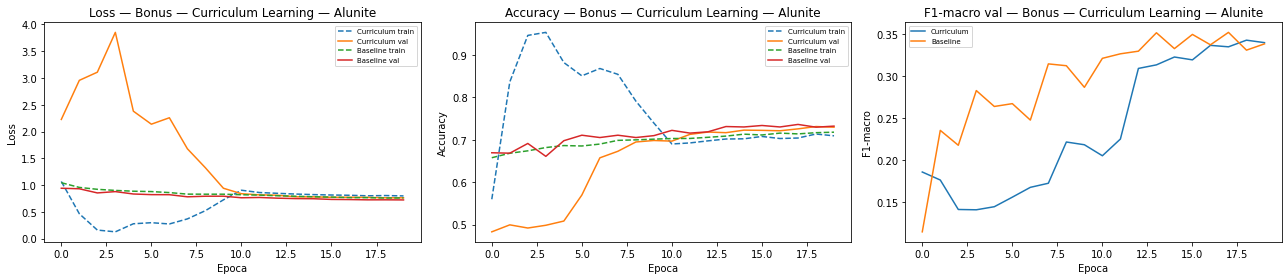

In [18]:
plot_history({'Curriculum': rez_curriculum, 'Baseline': rez_baseline},
	'Bonus — Curriculum Learning — Alunite',
	save_path='figures/fig_25_bonus_curriculum.png')